## Probability Distributions in SciPy.


- A Probability Distribution describes how the values of a random variable are distributed. It gives the probability of each possible outcome in a sample space. In SciPy, these are modeled using the scipy.stats module, which allows easy computation of PDFs, CDFs, moments, and random sampling.

In [2]:
# Example : Binomial Distribution.

from scipy.stats import binom

print(binom.pmf(3, n=10, p=0.5))    # PMF at k=3
print(binom.cdf(5, n=10, p=0.5))    # CDF at k=5
print(binom.rvs(n=10, p=0.6, size=5))  # Random samples


0.11718749999999999
0.623046875
[6 7 5 8 5]


## Types of Probability Distributions in SciPy.

## Discrete Probability Distributions.

- A Discrete Distribution describes the Probability of Finite or Countably Infinite Outcomes. Each Possible Outcome has an Associated Probability Mass.

- Examples: Tossing a Coin, Rolling a die, Number of Emails received in an Hour.

- Common Discrete Probability Distributions are : Binomial, Poisson, Bernoulli, Geometric, Negative Binomial and Hypergeometric. 

In [3]:
# Example : Discrete Probability Distributions.

from scipy.stats import binom, poisson, geom

# Binomial: 10 trials, p=0.5
print("Binomial PMF:", binom.pmf(3, n=10, p=0.5))
print("Binomial CDF:", binom.cdf(3, n=10, p=0.5))
print("Binomial Samples:", binom.rvs(10, 0.5, size=5))

# Poisson: λ=3
print("Poisson PMF:", poisson.pmf(2, mu=3))
print("Poisson Samples:", poisson.rvs(mu=3, size=4))

# Geometric: p=0.4
print("Geometric PMF:", geom.pmf(4, p=0.4))


Binomial PMF: 0.11718749999999999
Binomial CDF: 0.171875
Binomial Samples: [5 4 4 0 6]
Poisson PMF: 0.22404180765538775
Poisson Samples: [2 2 3 4]
Geometric PMF: 0.08639999999999999


## Features of Discrete Probability Distributions.

## Countable Outcomes(0, 1, 2, …).

- Discrete Distributions only take Specific, Countable Values — typically Integers.

In [4]:
# Example : Tossing a Coin 3 times(Binomial Distribution).

from scipy.stats import binom

n = 3       # number of trials
p = 0.5     # probability of success

# Possible outcomes: 0, 1, 2, 3 successes
for k in range(n + 1):
    print(f"P(X={k}) =", binom.pmf(k, n, p))


P(X=0) = 0.12499999999999997
P(X=1) = 0.3750000000000001
P(X=2) = 0.3750000000000001
P(X=3) = 0.125


## Uses Probability Mass Function (PMF) instead of PDF.

- PMF gives the Probability of a specific Discrete Value occurring.

In [5]:
## Example: Poisson Distribution(λ = 3).

from scipy.stats import poisson

mu = 3  # average rate

print("P(X=0):", poisson.pmf(0, mu))
print("P(X=1):", poisson.pmf(1, mu))
print("P(X=2):", poisson.pmf(2, mu))



P(X=0): 0.049787068367863944
P(X=1): 0.14936120510359185
P(X=2): 0.22404180765538775


## CDF is a Step Function.

- The Cumulative Distribution Function (CDF) increases in steps since Discrete Values jump from one to the next.

In [6]:
## Example: Geometric Distribution.

from scipy.stats import geom

p = 0.3  # success probability

for k in range(1, 6):
    print(f"CDF at k={k}:", geom.cdf(k, p))


CDF at k=1: 0.3
CDF at k=2: 0.51
CDF at k=3: 0.657
CDF at k=4: 0.7599
CDF at k=5: 0.8319300000000001


## Sum of All Probabilities is 1.

- The sum of PMFs over all possible outcomes equals 1.

In [8]:
# Example : Hypergeometric Distribution.

from scipy.stats import hypergeom
import numpy as np

M = 20  # total population
n = 7   # number of success states in population
N = 5   # number of draws

x = np.arange(0, 6)
pmf = hypergeom.pmf(x, M, n, N)
print("Sum of PMFs:", sum(pmf))


Sum of PMFs: 1.0


## Common Discrete Probability Distributions.

-  Binomial Distributions.
    
- Poisson Distributions.

- Bernoulli Distributions.

- Geometric Distributions.

- Negative Binomial Distributions.

- Hypergeometric Distributions.



## Binomial Distributions in Disctrete Distributions.

- A Bernoulli Experiment has only two outcomes: success (1) or failure (0).

- You Specify One Number p, the Probability of Success.

- All the Probability Mass sits on those Two Points, nothing in between.

- SciPy provides scipy.stats.bernoulli for this distribution.

In [13]:
# Example :  Probability of exactly 3 successes in 10 trials with p=0.5.

from scipy.stats import binom

prob = binom.pmf(3, n=10, p=0.5)
print(f"Probability of exactly 3 successes: {prob}")


Probability of exactly 3 successes: 0.11718749999999999


## Features of Binomial Distributions in Disctrete Distributions.

## Probability‑mass function (PMF).

- The PMF is P(X = 1) = p and P(X = 0) = 1 - p.

- Calling .pmf(x) returns exactly those values, 0 elsewhere.

- This lets you answer “what is the chance of success/failure?” directly.



In [10]:
from scipy.stats import bernoulli
rv = bernoulli(p=0.65)

print(rv.pmf(1))        # 0.65
print(rv.pmf(0))        # 0.35
print(rv.pmf(2))        # 0.0


0.65
0.3500000000000001
0.0


## Cumulative distribution function(CDF).

- The CDF jumps at 0 and 1: at 0 it equals 1 − p, at 1 it equals 1.
    
- It answers questions like “Probability the Putcome is ≤ x”.
    
- Between 0 and 1 the value stays flat, reflecting no mass inside.

In [11]:
print(rv.cdf(0))        # 0.35
print(rv.cdf(0.9))      # 0.35  (still flat)
print(rv.cdf(1))        # 1.0


0.35
0.35
1.0


## Mean and Variance.

- The Expected Value is exactly p; the Variance is p*(1-p).

- SciPy returns these with .mean() and .var(), so you never have to remember the formulas during exploratory work.



In [12]:
print(rv.mean())        # 0.65
print(rv.var())         # 0.22749999999999998


0.65
0.22749999999999998


## Poisson Distributions in Disctrete Distributions.


- The Poisson Distribution models the Number of Times an Event happens in a Fixed Interval of Time or Space, given that the Events happen Independently and at a Constant Average Rate.
  
- In SciPy, it's represented as scipy.stats.poisson.

In [1]:
# Example : Simple and Basic Example of Poisson Distributions.

from scipy.stats import poisson
prob = poisson.pmf(3, mu=2)  # Probability of 3 events when λ=2
print(prob)


0.18044704431548356


## Features of Poisson Distributions.

## Lambda (μ) as the Mean Rate.

- The Distribution has One Parameter mu (λ), which is both the Mean and the Variance. 
    
- It represents how many times an event is expected to occur per unit.

In [2]:
mean = poisson.mean(mu=5)
var = poisson.var(mu=5)
print(f"Mean: {mean}, Variance: {var}")


Mean: 5.0, Variance: 5.0


## Probability Mass Function(PMF).

- PMF gives the Probability of observing a Specific Number of Events. 
    
- pmf(k, mu) Calculates this for Integer k.



In [3]:
prob_0 = poisson.pmf(0, mu=4)
prob_5 = poisson.pmf(5, mu=4)
print(prob_0, prob_5)


0.01831563888873418 0.1562934518505317


## Cumulative Distribution Function(CDF).

- CDF gives the Probability of at most k Events Occurring. 
    
- This helps Understand Cumulative Probabilities.

In [4]:
cdf_val = poisson.cdf(3, mu=2.5)
print(f"Probability of ≤3 events: {cdf_val}")


Probability of ≤3 events: 0.7575761331330662


## One-Parameter Distribution(mu).

- Only One Parameter is needed — the Average Rate of Success(mu).

In [5]:
print(poisson.mean(mu=5))
print(poisson.var(mu=5))
print(poisson.pmf(3, mu=5))


5.0
5.0
0.1403738958142805


## PMF for Integer Events.

- You can Calculate Probabilities for any Count of Events.

In [6]:
print(poisson.pmf(0, mu=2))
print(poisson.pmf(4, mu=2))
print(poisson.pmf(7, mu=2))


0.1353352832366127
0.09022352215774178
0.0034370865583901616


## No Negative Values.

- The Poisson Distribution never Gives Negative Values.  It’s always 0 or more.

In [7]:
data = poisson.rvs(mu=3, size=1000)
print(min(data))  # Will always be >= 0


0


## Mean = Variance.

- Both the Mean and Variance are equal to mu.




In [8]:
print(poisson.mean(mu=8))  # 8
print(poisson.var(mu=8))   # 8


8.0
8.0


## Suitable for Count Data.

- Used when Measuring Counts over Time or Area.

In [9]:
# Counting errors in code per 1000 lines.

print(poisson.pmf(3, mu=2))


0.18044704431548356


## Skewed for Small mu.

- For small mu, the Distribution is Highly Right - Skewed.

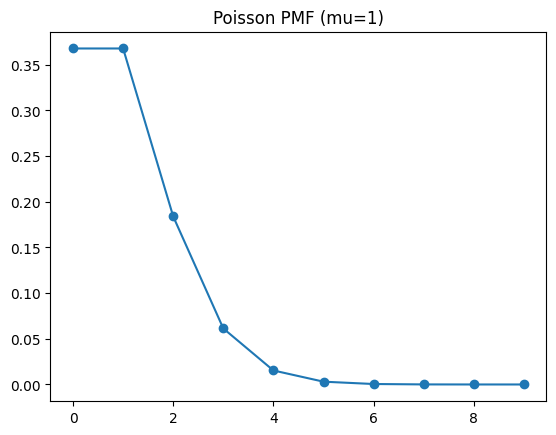

In [12]:
import numpy as np
import matplotlib.pyplot as plt
x = np.arange(0, 10)
pmf_vals = poisson.pmf(x, mu=1)
plt.plot(x, pmf_vals, marker='o')
plt.title("Poisson PMF (mu=1)")
plt.show()


## Bernoulli Distributions in Disctrete Distributions.

- The Bernoulli Distribution is the Simplest Discrete Probability Distribution. 
    
- It models a single trial that has only Two Possible Outcomes  : Success(1) or Failure(0).
    
- It uses a single parameter p, which is the probability of success.

In [21]:
## Probability of Success : Probability that a biased coin (p = 0.65) lands heads (1).

p = 0.65
prob_success = bernoulli.pmf(1, p)
print(prob_success)           # 0.65


0.65


## Features of Bernoulli Distributions.

## Only Two Outcomes – 0 or 1.

- Bernoulli Random Variable can only take 0(Failure) or 1(Success).
    
- There’s no in-between like 0.5 or 2.

In [14]:
outcomes = bernoulli.rvs(p=0.7, size=10)
print(outcomes)  # All values will be either 0 or 1


[1 0 0 0 1 0 1 1 1 0]


## One Parameter(p).

- Only One Parameter, p, is needed, which represents the Probability of success.
    
- The Probability of failure is automatically 1 - p.

In [15]:
p = 0.4
print(f"Success: {bernoulli.pmf(1, p)}")
print(f"Failure: {bernoulli.pmf(0, p)}")


Success: 0.4
Failure: 0.6


## Single Trial Modeling.

- Bernoulli Models One - Time Experiments, such as Flipping a Coin or Checking if a user clicks a button.

In [16]:
print(bernoulli.pmf(1, p=0.5))  # Coin lands on heads
print(bernoulli.pmf(0, p=0.5))  # Coin lands on tails


0.5
0.5000000000000001


## p + (1 - p) = 1.

- Always: P(success) + P(failure) = 1.



In [17]:
p = 0.8
print(bernoulli.pmf(1, p) + bernoulli.pmf(0, p))  # Always 1


1.0


## Mean = p, Variance = p(1 - p).

- Helps us Quickly Estimate Expected Value and Uncertainty.



In [18]:
print(bernoulli.mean(p=0.4))
print(bernoulli.var(p=0.4))


0.4
0.24


## Building Block for Binomial.

- Bernoulli is a special case of the Binomial distribution with n = 1.



In [19]:
from scipy.stats import binom
print(bernoulli.pmf(1, p=0.3))  # Same as binom.pmf(1, 1, 0.3)
print(binom.pmf(1, 1, 0.3))


0.3
0.3


## Best for Binary Classification.

- Use it when outcome is yes/no, success/failure, true/false.

## Used in Logistic Regression.

- Bernoulli models the output of Logistic Regression:
    
- P(success | x) = 1 / (1 + exp(-x))

## Geometric Distributions in Disctrete Distributions.

- The Geometric Distribution Models the Number of Bernoulli Trials needed to get the First Success.
  
- It is used when you're Repeating an Experiment until the First Success happens(like Rolling a Die until you get a 6).

## Features of Geometric Distributions.

## Discrete Distribution – Counts Trials Until First Success.

- Unlike Bernoulli(1 trial) or Binomial(fixed trials), Geometric counts how many Failures happen before the First Success.

In [13]:
from scipy.stats import geom
print(geom.pmf(1, p=0.3))  # Probability that success occurs on 1st trial


0.3


## Uses Probability Mass Function(PMF).

- geom.pmf(k, p) gives the probability that the first success occurs on the k-th trial.

In [14]:
print(geom.pmf(1, p=0.6))  # Success on first trial
print(geom.pmf(2, p=0.6))  # Failure first, then success


0.6
0.24


## One Parameter – Probability of Success(p).

- It only needs One Parameter : The Probability of Success in each Trial.

In [15]:
p = 0.4
print(geom.pmf(3, p))  # Success on 3rd trial


0.144


## Mean and Variance.
    
- Mean = 1/p

- Variance = (1 - p) / p², So if p is Small, the Mean(Expected Number of Trials) is Larger.


In [16]:
print(geom.mean(p=0.25))    # Expect 4 trials
print(geom.var(p=0.25))     # High variance if p is low


4.0
12.0


## Models Wait Until Success Problems.

- Examples :

- Toss a Coin until heads

- Retry a network request until it works.

- Keep applying for jobs until hired

In [18]:
# Probability of first success on 5th try(After 4 Failures).
print(geom.pmf(5, p=0.2))


0.08192000000000002


## Single Parameter Model.

- Only the Success Probability p is Required.

In [19]:
print(geom.pmf(2, p=0.5))
print(geom.pmf(4, p=0.1))


0.25
0.0729


## Easy to Compute Mean & Variance.

- Simple formulas based on p make it efficient for modeling.



In [20]:
print("Mean:", geom.mean(p=0.25))
print("Variance:", geom.var(p=0.25))


Mean: 4.0
Variance: 12.0


## High Variance When p is Low.

- If Success is Rare(small p), it may take many tries.



In [21]:
print("Mean:", geom.mean(p=0.1))
print("Variance:", geom.var(p=0.1))


Mean: 10.0
Variance: 90.0


## Negative Binomial Distributions in Disctrete Distributions.

- The Negative Binomial Distribution Models the Number of Failures before Achieving a Fixed Number of Successes in a Sequence of Independent Bernoulli Trials.


## It counts Failures until a Set Number of Successes.

In [3]:
from scipy.stats import nbinom

# Probability of Getting 3 Failures before 5 Successes(p=0.4).

prob = nbinom.pmf(3, 5, 0.4)
print("P(X=3):", prob)


P(X=3): 0.0774144


## It’s a Generalization of Geometric Distribution.

In [4]:
# Geometric is a special case when r=1.

geom_like = nbinom.pmf(2, 1, 0.5)
print("Geometric-like PMF:", geom_like)


Geometric-like PMF: 0.12499999999999997


## It models Over-Dispersed Count Data(Variance > Mean).

In [5]:
r, p = 5, 0.3
mean, var = nbinom.mean(r, p), nbinom.var(r, p)
print("Mean:", mean, "Variance:", var)


Mean: 11.666666666666668 Variance: 38.88888888888889


## It is useful in Modeling Repeated Trials like Quality Control.

In [7]:
# Probability of 4 failures before 3 successful quality checks(p=0.6).

print(nbinom.pmf(4, 3, 0.6))


0.08294400000000006


## It’s Discrete(Non-Continuous) and only deals with Integers.



In [8]:
import numpy as np
x = np.arange(0, 10)
pmf = nbinom.pmf(x, 3, 0.5)
print("Discrete PMF values:", pmf)


Discrete PMF values: [0.125      0.1875     0.1875     0.15625    0.1171875  0.08203125
 0.0546875  0.03515625 0.02197266 0.01342773]


## The Probability Mass Function is defined for x = 0, 1, 2...

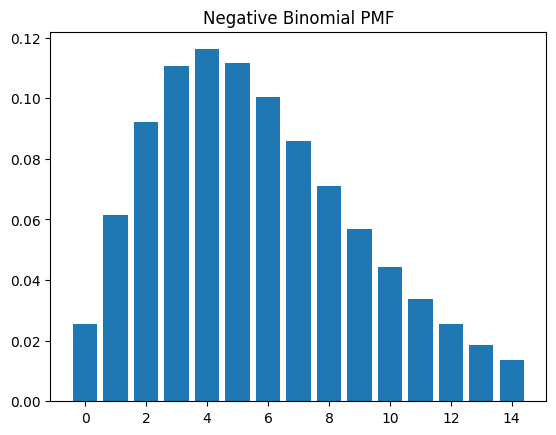

In [9]:
import matplotlib.pyplot as plt

x = np.arange(0, 15)
plt.bar(x, nbinom.pmf(x, 4, 0.4))
plt.title("Negative Binomial PMF")
plt.show()


## The Distribution depends on:

- r(Number of Successes).

- p(Probability of Success).

In [10]:
r, p = 3, 0.7
print("Probability for 0, 1, 2 failures:", nbinom.pmf([0,1,2], r, p))


Probability for 0, 1, 2 failures: [0.343   0.3087  0.18522]


## CDF gives Cumulative Probabilities(≤ x).

In [11]:
print("CDF for ≤3 failures:", nbinom.cdf(3, 4, 0.6))


CDF for ≤3 failures: 0.710208


## Skewness is always Positive(Right-Skewed).

In [12]:
print("Skewness:", nbinom.stats(3, 0.3, moments='s'))


Skewness: 1.1731114508820022


## Features of Negative Binomial Distribution.

## The Negative Binomial Distribution calculates the number of failures that occur before a defined Number of Successes(r). It is particularly useful when you're waiting for a certain number of successful outcomes over repeated Independent Trials with Fixed Probability p.

In [13]:
from scipy.stats import nbinom

print("P(2 failures before 3rd success):", nbinom.pmf(2, 3, 0.5))
print("P(0 failures before 1st success):", nbinom.pmf(0, 1, 0.6))
print("P(4 failures before 5th success):", nbinom.pmf(4, 5, 0.7))
print("P(10 failures before 8th success):", nbinom.pmf(10, 8, 0.3))


P(2 failures before 3rd success): 0.1875
P(0 failures before 1st success): 0.5999999999999998
P(4 failures before 5th success): 0.09529569000000013
P(10 failures before 8th success): 0.036043369473783705


## Discrete Probability Distribution(Integer Outcomes Only).


- The Negative Binomial is a Discrete Distribution—it only allows Integer values for the Number of Failures(0, 1, 2,...). It is not suitable for Modeling Continuous or Fractional Outcomes.

In [14]:
x = list(range(10))
pmf_vals = nbinom.pmf(x, 3, 0.5)
print("PMF values (integer x):", pmf_vals)

print("Integer input example:", nbinom.pmf(6, 4, 0.5))
print("Another integer input:", nbinom.pmf(2, 2, 0.7))
print("Decimal input gets zero prob:", nbinom.pmf(2.5, 2, 0.7))  # May return 0.0 or error


PMF values (integer x): [0.125      0.1875     0.1875     0.15625    0.1171875  0.08203125
 0.0546875  0.03515625 0.02197266 0.01342773]
Integer input example: 0.08203125000000003
Another integer input: 0.13229999999999995
Decimal input gets zero prob: 0.0


## Depends on Two Parameters - r(Successes), p(Probability).

- It is Parameterized by:

- r  : Number of Successes

- p  : Probability of a Success in one Trial.
    
- These Two Parameters control the Shape and Spread of the Distribution.

In [16]:
print("r=3, p=0.6, P(X=2):", nbinom.pmf(2, 3, 0.6))
print("r=5, p=0.3, P(X=4):", nbinom.pmf(4, 5, 0.3))
print("r=1, p=0.5 (geometric):", nbinom.pmf(3, 1, 0.5))
print("Mean for r=5, p=0.4:", nbinom.mean(5, 0.4))


r=3, p=0.6, P(X=2): 0.20736000000000002
r=5, p=0.3, P(X=4): 0.04084100999999999
r=1, p=0.5 (geometric): 0.062499999999999986
Mean for r=5, p=0.4: 7.5


## Skewed Distribution(Right- Skewed).

- The Distribution is typically Right- Skewed, especially when the Success Probability p is Low. This means more Mass lies toward Lower Numbers, and a long tail stretches to the right.

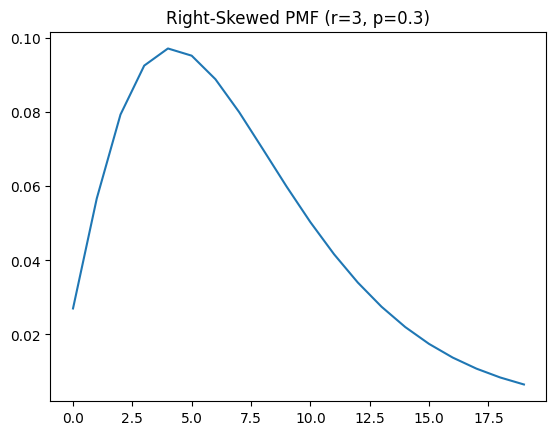

1.1731114508820022
0.05033708937180001
0.05669999999999997


In [17]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(0, 20)
plt.plot(x, nbinom.pmf(x, 3, 0.3))
plt.title("Right-Skewed PMF (r=3, p=0.3)")
plt.show()

print(nbinom.stats(3, 0.3, moments='s'))  # Skewness
print(nbinom.pmf(10, 3, 0.3))  # Tail value
print(nbinom.pmf(1, 3, 0.3))   # Peak value


## Generalization of Geometric Distribution.

- When r = 1, the Negative Binomial becomes a Geometric Distribution, measuring the Number of Failures before the First Success.

In [19]:
# Geometric as special case.


print("Geometric P(X=2):", nbinom.pmf(2, 1, 0.4))
print("Geometric CDF:", nbinom.cdf(3, 1, 0.4))
print("Geometric mean:", nbinom.mean(1, 0.4))
print("Geometric variance:", nbinom.var(1, 0.4))


Geometric P(X=2): 0.14400000000000002
Geometric CDF: 0.8704000000000001
Geometric mean: 1.4999999999999998
Geometric variance: 3.749999999999999


## Calculating Mean, Variance, Skewness, and Kurtosis in Negative Binomial Distribution in Discrete Distribution.


- The Mean of a Negative Binomial Distribution is  :  Mean = (r * (1 - p)) / p.

- The Variance is  :  Variance = r * (1 - p) / p^2.

- The Skewness is Positive, meaning the Distribution is Right - Skewed.

- It implies a Longer tail on the Right side, especially when p is Small.

- Kurtosis measures Tail Heaviness and Peakedness Relative to a Normal Distribution.

- These Metrics help Evaluate Fit and compare with Poisson or Binomial distributions.

- Higher r with Fixed p makes the Distribution more Symmetric.

- Lower p values Stretch the Distribution with Higher Variance.

- All Moments depend Strongly on r and p.

- We can use scipy.stats.nbinom Functions to compute all Moments.

- These stats are crucial for Simulation, Model Fitting, and Parameter Tuning

In [20]:
r, p = 3, 0.4

# Example 1: Mean
print("Mean:", nbinom.mean(r, p))

# Example 2: Variance
print("Variance:", nbinom.var(r, p))

# Example 3: Skewness
print("Skewness:", nbinom.stats(r, p, moments='s'))

# Example 4: Kurtosis
print("Kurtosis:", nbinom.stats(r, p, moments='k'))

# Example 5: Compare mean and variance
sample = nbinom.rvs(r, p, size=1000)
print("Empirical mean:", np.mean(sample))
print("Empirical variance:", np.var(sample))


Mean: 4.499999999999999
Variance: 11.249999999999996
Skewness: 1.1925695879998879
Kurtosis: 2.088888888888889
Empirical mean: 4.593
Empirical variance: 13.201350999999999


## Comparing with Poisson and Binomial Distributions.

- Poisson assumes Constant Mean = Variance; NB allows Variance > Mean.

- Binomial Models nNumber of successes; NB models Failures before Successes.

- NB is more Flexible, especially for Overdispersed count data.

- Poisson fails when data has many zeros or high variance.

- NB includes geometric as a special case (r=1).

- Binomial is fixed-trial; NB has variable-length trials.

- Mean and Variance for Poisson are equal — restrictive in real-world cases.

- In count-based modeling (e.g., regression), NB often outperforms Poisson.

- NB is preferred for accident data, email counts, claims, etc.

- Visual Comparison helps understand Differences.

- Use metrics like AIC or BIC to compare model fits.

- Always examine sample stats before choosing a Distribution.

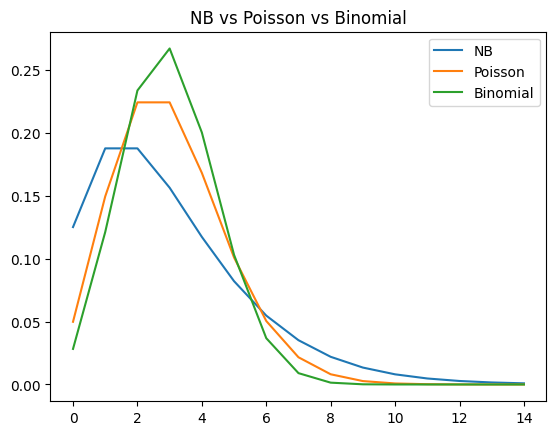

NB Variance > Mean? True
Poisson Var ≈ Mean? 3.0192160000000006 2.972


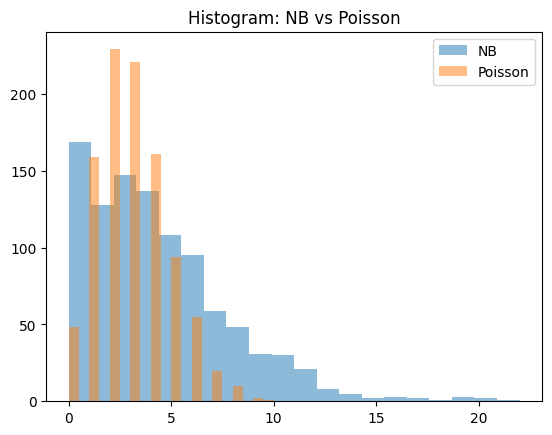

In [22]:
from scipy.stats import poisson, binom

# Example 1: Compare PMFs
x = np.arange(0, 15)
plt.plot(x, nbinom.pmf(x, 3, 0.5), label="NB")
plt.plot(x, poisson.pmf(x, 3), label="Poisson")
plt.plot(x, binom.pmf(x, 10, 0.3), label="Binomial")
plt.legend()
plt.title("NB vs Poisson vs Binomial")
plt.show()

# Example 2: Sample and compare stats
nb_sample = nbinom.rvs(3, 0.4, size=1000)
pois_sample = poisson.rvs(3, size=1000)
print("NB Variance > Mean?", np.var(nb_sample) > np.mean(nb_sample))
print("Poisson Var ≈ Mean?", np.var(pois_sample), np.mean(pois_sample))

# Example 3: Visualize NB vs Poisson histograms
plt.hist(nb_sample, bins=20, alpha=0.5, label="NB")
plt.hist(pois_sample, bins=20, alpha=0.5, label="Poisson")
plt.legend()
plt.title("Histogram: NB vs Poisson")
plt.show()


## Continous Distribution in SciPy.


- Continuous Distributions model Random Variables that can take any Real Value within a range.

- These Distributions have Infinite Possible Outcomes, unlike Discrete Ones(which have Countable Values).

- The Probability of any Exact Value is Zero; instead, we Calculate the Probability Density over Intervals.

- Examples include Normal, Exponential, Uniform, Gamma, etc.

- In SciPy, Continuous Distributions are Implemented in the scipy.stats Module.

- They are Object - Oriented, so each Distribution is an object with methods like .pdf(), .cdf(), .ppf(), .rvs().

- .pdf() gives the Probability Density Function.

- .cdf() gives the Cumulative Distribution Function.

- .rvs() generates random samples from the distribution.

- .ppf() gives the percent-point function (inverse of CDF).

- Many distributions are parameterized by values like Mean, Variance, Shape, or Scale.

- Continuous Distributions are used in Modelling Natural Phenomena like Height, Temperature, Time - to - Failure, etc.



0.3989422804014327
0.9750021048517795
1.959963984540054
[-0.81841005  1.82035038  0.32393794 -1.54957096  0.62841754]
0.25
0.5
0.1353352832366127
[1.14416166 4.6169005  1.46582538]


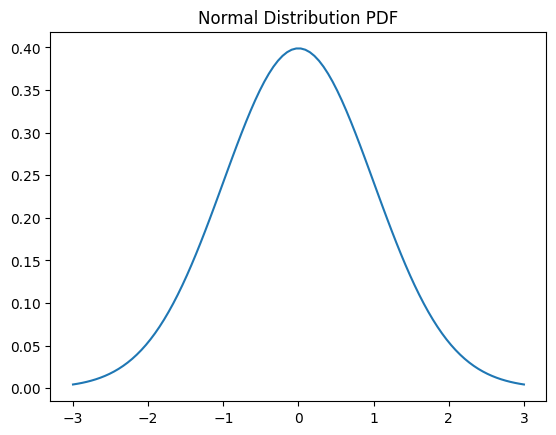

Mean: 0.0 Variance: 1.0


In [23]:
from scipy.stats import norm, uniform, expon
import numpy as np

# 1. PDF of Normal distribution
print(norm.pdf(0, loc=0, scale=1))

# 2. CDF of Normal distribution
print(norm.cdf(1.96))

# 3. Inverse CDF (PPF)
print(norm.ppf(0.975))

# 4. Random sample from Normal distribution
print(norm.rvs(loc=0, scale=1, size=5))

# 5. PDF of Uniform distribution
print(uniform.pdf(2, loc=1, scale=4))  # from 1 to 5

# 6. CDF of Uniform distribution
print(uniform.cdf(3, loc=1, scale=4))

# 7. PDF of Exponential distribution
print(expon.pdf(2, scale=1))  # lambda = 1

# 8. Random sample from Exponential distribution
print(expon.rvs(scale=2, size=3))

# 9. Plot PDF of normal distribution
import matplotlib.pyplot as plt
x = np.linspace(-3, 3, 100)
plt.plot(x, norm.pdf(x))
plt.title("Normal Distribution PDF")
plt.show()

# 10. Mean and Variance
print("Mean:", norm.mean(), "Variance:", norm.var())


## Features of Continuous Distributions in SciPy.

## PDF(Probability Density Function).

- The PDF gives the likelihood of a random variable being near a specific value. 
- For continuous distributions, it doesn't give actual probability but a density, since exact values have zero probability. 
- The area under the curve between two points gives the probability of falling within that range. PDF shapes differ per distribution (e.g., bell-shaped for normal, flat for uniform).

In [1]:
from scipy.stats import norm, expon, uniform
print(norm.pdf(0))             # Standard normal at x=0
print(expon.pdf(2, scale=1))   # Exponential PDF at x=2
print(uniform.pdf(3, loc=2, scale=4))  # Uniform from [2,6]
print(norm.pdf([-1, 0, 1]))    # Vector input for multiple values


0.3989422804014327
0.1353352832366127
0.25
[0.24197072 0.39894228 0.24197072]


## CDF(Cumulative Distribution Function).

- CDF gives the Probability that a Random Variable is less than or equal to a given Value. 
- It always ranges from 0 to 1 and is Monotonically Increasing. For example, CDF of 0.5 in a normal distribution means the variable is below that value with 50% chance. It’s useful for range-based probabilities.

In [2]:
print(norm.cdf(0))                 # P(X <= 0)
print(expon.cdf(1.5, scale=2))     # Exponential CDF
print(uniform.cdf(3, loc=2, scale=4))  # Uniform CDF
print(norm.cdf([-2, 0, 2]))        # Vectorized


0.5
0.5276334472589853
0.25
[0.02275013 0.5        0.97724987]


## Random Sampling(rvs method).

-  The .rvs() method generates random samples from the distribution. 
- It’s used in simulations, Monte Carlo methods, and synthetic data generation. You can specify how many values you want using the size parameter. Distributions can be parameterized with shape, loc, and scale values.

In [3]:
print(norm.rvs(size=5))                 # 5 normal samples
print(expon.rvs(scale=2, size=3))       # 3 exponential samples
print(uniform.rvs(loc=5, scale=3, size=4))  # Uniform [5, 8]
print(norm.rvs(loc=100, scale=15, size=10))  # Like IQ scores


[-0.9266479  -0.74399844 -0.84451544 -0.9590767  -0.95976772]
[3.44931496 0.23539452 4.5292061 ]
[7.03726756 6.00756581 7.71192365 6.35049569]
[ 97.14320018 100.81142432 103.67592572 120.12474664 108.38533327
 105.436551    91.07347412  89.74015554  79.77217339  91.48481893]


## PPF(Percent Point Function – Inverse CDF).

- The PPF returns the value of a variable at a given percentile. 
- It's the inverse of CDF. For example, the 0.975 quantile in a normal distribution corresponds to ~1.96 (for 95% confidence). 
- It’s used in confidence interval calculations and decision thresholds.


In [4]:
print(norm.ppf(0.975))          # 97.5th percentile (≈1.96)
print(expon.ppf(0.5))           # Median of exponential
print(uniform.ppf(0.25, loc=0, scale=10))  # 25th percentile
print(norm.ppf([0.25, 0.5, 0.75]))        # Multiple percentiles


1.959963984540054
0.6931471805599453
2.5
[-0.67448975  0.          0.67448975]


## Moments – Mean, Variance, Skew, Kurtosis.

- We can Compute Statistical Moments using .mean(), .var(), or .stats() Methods. 
- This helps in summarizing a distribution’s shape. Mean shows center, variance shows spread, skew shows symmetry, and kurtosis shows peak/flatness. Useful in data analysis and understanding distribution behavior.

In [5]:
print(norm.mean(), norm.var())              # Standard normal
print(expon.stats(moments='mvsk'))          # All moments
print(uniform.stats(loc=0, scale=10, moments='mvsk'))  # Uniform
print(norm.stats(moments='mvs'))            # Mean, variance, skew


0.0 1.0
(1.0, 1.0, 2.0, 6.0)
(5.0, 8.333333333333332, 0.0, -1.2)
(0.0, 1.0, 0.0)


## Parameterization with loc and scale.

- Most SciPy Distributions support loc(location or mean shift) and scale (spread/stretch). 
- These parameters allow you to customize distributions. Some have shape Parameters too, e.g., a, b. 
- This makes them Flexible and Applicable in Real - World Scenarios.

In [6]:
print(norm.pdf(2, loc=2, scale=1))          # Shifted normal
print(expon.pdf(1, scale=2))                # Lambda = 1/2
print(uniform.pdf(4, loc=2, scale=4))       # Uniform from 2 to 6
print(norm.rvs(loc=10, scale=2, size=5))    # Custom normal


0.3989422804014327
0.3032653298563167
0.25
[ 9.40438771 10.06239731  7.21880186  8.87347386  5.74051872]


## Broadcasting & Vectorized Computation.

- Most SciPy Functions work with NumPy Arrays, allowing you to calculate PDF, CDF, etc., for Multiple Values at once. 
- This enables fast, efficient computations without loops. It's ideal for large datasets or simulations.

In [7]:
import numpy as np
x = np.linspace(-3, 3, 5)
print(norm.pdf(x))     # PDF for all x values
print(norm.cdf(x))     # CDF for all x
print(expon.rvs(size=(2, 3)))  # 2D array of random samples
print(uniform.pdf([1, 2, 3], loc=0, scale=4))


[0.00443185 0.1295176  0.39894228 0.1295176  0.00443185]
[0.0013499 0.0668072 0.5       0.9331928 0.9986501]
[[0.32094268 0.42189991 2.49309071]
 [0.62638523 0.23641191 1.46702807]]
[0.25 0.25 0.25]


## Types of Continuous Distributions in SciPy.

- Normal(Gaussian) – Symmetric, Bell- Shaped, defined by Mean & Std.

- Exponential – Time between events in Poisson Processes.

- Uniform – Equal Probability across interval.

- Beta – Used for Probabilities, bounded between 0 and 1.

- Gamma – Used in Queuing, Reliability.

- Chi-square – Sum of squares of normal variables.

- Log-normal – If log(X) is normal, X is log-normal.

- t-distribution – Used in small-sample statistics.

- F-distribution – Ratio of two chi-squares, used in ANOVA.



In [8]:
from scipy.stats import beta, gamma, chi2, lognorm, weibull_min, rayleigh, pareto, t, f

print(beta.pdf(0.5, a=2, b=5))
print(gamma.pdf(2, a=3))
print(chi2.pdf(3, df=4))
print(lognorm.pdf(2, s=0.5))
print(weibull_min.pdf(1, c=1.5))
print(rayleigh.pdf(2))
print(pareto.pdf(2, b=3))
print(t.pdf(2, df=10))
print(f.pdf(1, dfn=5, dfd=2))


0.9374999999999999
0.2706705664732254
0.1673476201113224
0.15261382604754578
0.5518191617571635
0.2706705664732254
0.1875
0.061145766321218174
0.30800082169406595


## Normal(Gaussian) Distribution in Continous Distribution in SciPy.

- The Normal Distribution(also called Gaussian Distribution) is a Bell - Shaped Curve that is Symmetric about the Mean.

- It is defined by Two Parameters : Mean (μ) and Standard Deviation(σ).

- It is one of the most Commonly used Distributions in Statistics, Data Science etc.

- The Total Area under the Curve is 1, representing a Full Probability.

- About 68% of the data falls within ±1σ, 95% within ±2σ, and 99.7% within ±3σ(Empirical Rule).

- The Probability Density Function (PDF) is  :  f(x)  =  1 / sqrt(2.pie.(sigma)^2 . e^-(x - mu)^2 / 2.(sigma)^2.

- It is used in IQ scores, measurement errors, stock returns, and more.

- In SciPy, it is represented as: scipy.stats.norm

- If μ = 0 and σ = 1, it is called the standard normal distribution.

- It allows calculation of PDF, CDF, random samples, intervals, etc.

- It's used for Confidence Intervals, Hypothesis Testing, and many Machine Learning Applications.

- Easy to simulate using .rvs(), and analyze using .pdf(), .cdf(), .ppf(), etc.

 - It is used in IQ scores, Measurement Errors, Stock Returns, and more.



## Examples of Normal(Gaussian) Distribution in SciPy.

## Generating Random Values(Simulation).

In [9]:
from scipy.stats import norm
import numpy as np

# Standard normal random values
samples = norm.rvs(size=5)
print("Random Samples:", samples)

# Random samples with mean=100, std=15
iq_scores = norm.rvs(loc=100, scale=15, size=10)
print("Simulated IQ Scores:", iq_scores)


Random Samples: [-1.53969286  0.91421131  1.15003449 -1.13265386  0.75103151]
Simulated IQ Scores: [ 98.55481754  82.16636056  79.8677465   90.7201945   89.38767757
  79.45922526 105.52240669 132.85873042  75.82119005 113.72298433]


## Probability Density Function(PDF).

In [11]:
# PDF at x = 0(Standard Normal).

print("PDF at 0:", norm.pdf(0))

# PDF at x = 100 for IQ distribution (mean=100, std=15).

print("PDF at 100:", norm.pdf(100, loc=100, scale=15))

# Vector PDF.

x = np.array([90, 100, 110])
pdf_vals = norm.pdf(x, loc=100, scale=15)
print("PDF for IQ scores:", pdf_vals)


PDF at 0: 0.3989422804014327
PDF at 100: 0.02659615202676218
PDF for IQ scores: [0.02129653 0.02659615 0.02129653]


## Cumulative Distribution Function(CDF).

In [14]:
# CDF at 0.

print("P(X <= 0):", norm.cdf(0))

# P(IQ ≤ 115).

print("P(IQ ≤ 115):", norm.cdf(115, loc=100, scale=15))

# Vector CDF.

cdf_vals = norm.cdf([85, 100, 115], loc=100, scale=15)
print("CDF for IQ scores:", cdf_vals)


P(X <= 0): 0.5
P(IQ ≤ 115): 0.8413447460685429
CDF for IQ scores: [0.15865525 0.5        0.84134475]


## Percent Point Function(Inverse CDF / Quantiles).

In [16]:
# Median(50th percentile).

print("Median IQ:", norm.ppf(0.5, loc=100, scale=15))

# 95th percentile IQ.

print("95th percentile:", norm.ppf(0.95, loc=100, scale=15))

# Quantiles for Confidence Interval.

ci = norm.ppf([0.025, 0.975], loc=100, scale=15)
print("95% Confidence Interval:", ci)


Median IQ: 100.0
95th percentile: 124.67280440427209
95% Confidence Interval: [ 70.60054023 129.39945977]


## Fitting Normal Distribution to Data.

In [18]:
# Simulated data.

data = norm.rvs(loc=50, scale=8, size=100)

# Fit the Distribution.

mu, std = norm.fit(data)
print("Fitted Mean:", mu)
print("Fitted Std Dev:", std)


Fitted Mean: 50.35518009384859
Fitted Std Dev: 7.014176344657941


## Features of Normal Distribution(Gaussian) Distribution in SciPy.

## Symmetry Around the Mean.

- The Normal distribution is perfectly symmetric around its mean (μ).

- This means the left and right sides of the curve mirror each other.

- The Mean, Median, and Mode are equal in a Normal Distribution.

- It is often used when data is naturally balanced, such as height or test scores.

- Data follows the Empirical Rule (68-95-99.7% within 1σ, 2σ, 3σ).

- Outliers are rare due to the rapid decrease in tails.

- Most Machine learning algorithms assume normality in inputs.

- The distribution's symmetry allows for simplified confidence intervals.

- This property is crucial for Parametric Tests like t-tests and z-tests.

- Standardization via z-scores depends on this Symmetry.

- Real - World data often approximate a Normal Shape.

- It's ideal when we want equal Probability above and below the Mean.

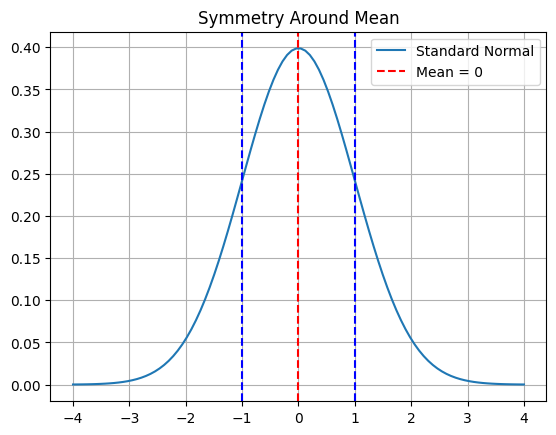

In [20]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np

# Plotting symmetry
x = np.linspace(-4, 4, 100)
plt.plot(x, norm.pdf(x), label='Standard Normal')
plt.axvline(0, color='red', linestyle='--', label='Mean = 0')
plt.axvline(-1, color='blue', linestyle='--')
plt.axvline(1, color='blue', linestyle='--')
plt.title("Symmetry Around Mean")
plt.legend()
plt.grid(True)
plt.show()


In [21]:
# Checking values around the Mean.

print("PDF(-1) =", norm.pdf(-1))
print("PDF(1)  =", norm.pdf(1))  # Should be equal due to symmetry


PDF(-1) = 0.24197072451914337
PDF(1)  = 0.24197072451914337


In [22]:
# Symmetry in Probabilities.

print("P(X < -1):", norm.cdf(-1))
print("P(X > 1):", 1 - norm.cdf(1))


P(X < -1): 0.15865525393145707
P(X > 1): 0.15865525393145707


In [23]:
# Z - Score Usage.

z = (110 - 100) / 10  # mean=100, std=10
print("Z-Score for 110:", z)
print("P(X < 110):", norm.cdf(z))


Z-Score for 110: 1.0
P(X < 110): 0.8413447460685429


## Defined by Mean and Standard Deviation.

- A Normal Distribution is completely defined by its mean (μ) and standard deviation (σ).

- The Mean sets the center, while σ controls the spread or width.

- A larger σ means a wider curve, smaller σ means a tighter curve.

- You can model different real-life scenarios by adjusting μ and σ.

- Examples include human IQ (μ=100, σ=15) or height.

- The peak (highest point of the curve) is always at the mean.

- All Probabilities are computed in relation to these parameters.

- norm() in SciPy accepts loc=mean and scale=std.

- These values make the curve flexible for many domains.

- fit() function estimates them from real data.

- Changing just σ with fixed μ stretches or shrinks the curve.

- Changing just μ shifts the Curve Horizontally.

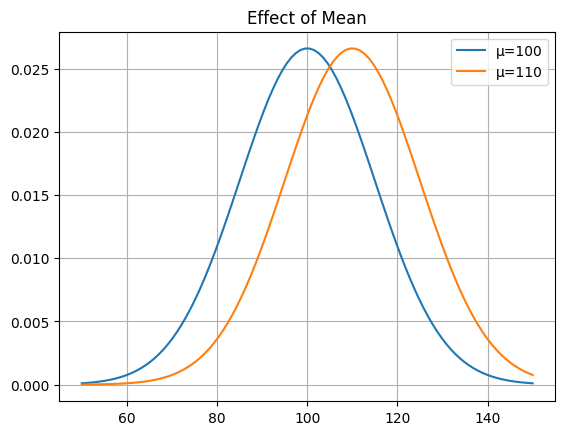

In [24]:
# Plotting with different means and same std.

x = np.linspace(50, 150, 100)
plt.plot(x, norm.pdf(x, loc=100, scale=15), label='μ=100')
plt.plot(x, norm.pdf(x, loc=110, scale=15), label='μ=110')
plt.title("Effect of Mean")
plt.legend(); plt.grid(True); plt.show()


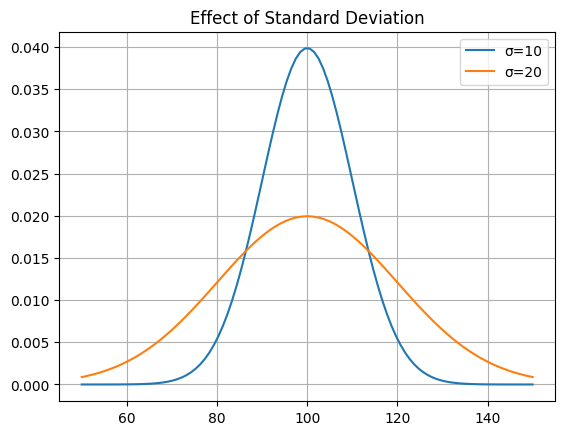

In [25]:
# Plotting with same mean and different std.

plt.plot(x, norm.pdf(x, loc=100, scale=10), label='σ=10')
plt.plot(x, norm.pdf(x, loc=100, scale=20), label='σ=20')
plt.title("Effect of Standard Deviation")
plt.legend(); plt.grid(True); plt.show()


In [26]:
# Random samples from custom normal.

samples = norm.rvs(loc=50, scale=5, size=5)
print("Random Samples:", samples)


Random Samples: [52.27305167 52.97979842 51.35091111 48.09871968 47.89832362]


In [27]:
# Fit Parameters from data.

data = norm.rvs(loc=60, scale=7, size=100)
mean, std = norm.fit(data)
print("Estimated Mean:", mean)
print("Estimated Std:", std)


Estimated Mean: 59.49649063565996
Estimated Std: 7.125884425156986


In [28]:
# Mean and Variance Functions.

print("Mean:", norm.mean(loc=100, scale=15))
print("Variance:", norm.var(loc=100, scale=15))


Mean: 100.0
Variance: 225.0


## Applications in Statistical Analysis.

- The Normal Distribution is essential in Inferential Statistics.

- It's used in z-tests, t-tests, and Regression Assumptions.

- Many natural phenomena like height and IQ follow this distribution.

- The Central Limit Theorem says Sample means tend to be Normal.

- It's used in Confidence Intervals and Prediction Intervals.

- Measurement errors in physics and experiments often follow it.

- It helps compute tail risks in finance and value-at-risk (VaR).

- Machine Learning Models often assume Normality in Residuals.

- It supports hypothesis testing in experiments and A/B tests.

- It forms the basis of Gaussian Naive Bayes classifiers.

- Simulations and Synthetic Data Generation rely on it.

- Helps model noise in communication systems

In [30]:
# Confidence Interval for IQ(μ=100, σ=15).

ci = norm.ppf([0.025, 0.975], loc=100, scale=15)
print("95% Confidence Interval:", ci)


95% Confidence Interval: [ 70.60054023 129.39945977]


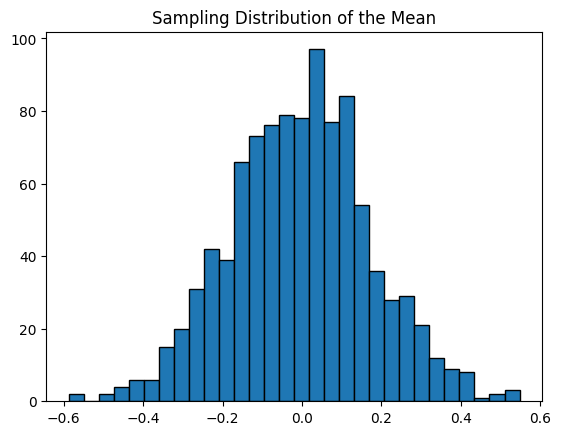

In [31]:
# Central Limit Theorem Illustration.

means = [np.mean(norm.rvs(size=30)) for _ in range(1000)]
plt.hist(means, bins=30, edgecolor='k')
plt.title("Sampling Distribution of the Mean")
plt.show()


In [33]:
# Hypothesis Testing : Is score > 120 significant or not.

z = (120 - 100) / 15
p = 1 - norm.cdf(z)
print("P-value:", p)


P-value: 0.09121121972586788


In [34]:
# Z-test Example.

sample_mean = 105
pop_mean = 100
std_dev = 10
n = 30
z = (sample_mean - pop_mean) / (std_dev / np.sqrt(n))
p_value = 1 - norm.cdf(z)
print("Z-Score:", z, "P-Value:", p_value)


Z-Score: 2.7386127875258306 P-Value: 0.0030849496602720627


In [35]:
# Simulation with Noise.

true_values = np.linspace(50, 60, 10)
noise = norm.rvs(scale=1, size=10)
measured = true_values + noise
print("Measured Values with Noise:", measured)


Measured Values with Noise: [51.25713807 50.05709289 50.37536169 51.824337   52.49203344 56.08009504
 56.26192728 58.60870342 60.20134923 60.92473577]


## Uniform Distribution in Continous Distribution in SciPy.


- The Uniform Distribution is a Probability Distribution where every value in a given Range has the same Chance of Occurring.

- For example, in a range from 0 to 10, every number between 0 and 10 has the same probability of being selected.

In [37]:
from scipy.stats import uniform

# Random number between 0 and 10.

print("Sample:", uniform.rvs(loc=0, scale=10))


Sample: 5.892008963340394


## It’s Called a Rectangular Distribution.

- The shape of the Uniform Distribution’s PDF(Probability Density Function) is a Flat, Straight Line — like a Rectangle.
    
- That's why it's sometimes called a Rectangular Distribution.

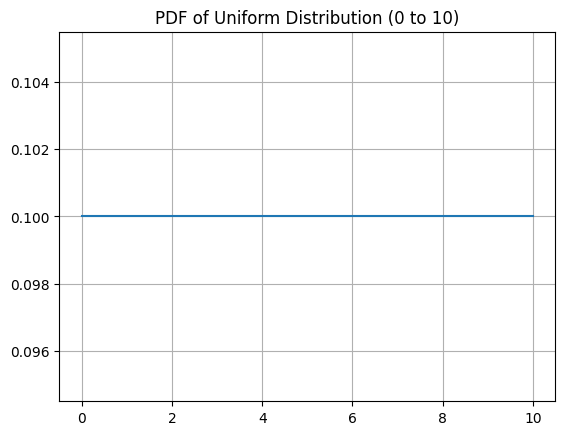

In [39]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 100)
pdf = uniform.pdf(x, loc=0, scale=10)

plt.plot(x, pdf)
plt.title("PDF of Uniform Distribution (0 to 10)")
plt.grid(True)
plt.show()


## Defined by Start(loc) and Width(scale).

- In SciPy, a Uniform Distribution is defined by:

- loc  :  Starting point of the Interval.

- scale: Width of the Interval.

- So, a Uniform distribution from 5 to 15 is loc=5, scale=10.

In [41]:
# Random value between 5 and 15.

value = uniform.rvs(loc=5, scale=10)
print("Value between 5 and 15:", value)


Value between 5 and 15: 8.333769819717848


## Probability Density is Constant.


- For any point within the Interval, the Probability Density is constant  : PDF = 1 / 𝑏 - a.
 
- This means no value is more likely than another in the Interval.

In [43]:
# PDF value at x = 7 for a distribution from 5 to 15.

pdf_value = uniform.pdf(7, loc=5, scale=10)
print("PDF at x = 7:", pdf_value)


PDF at x = 7: 0.1


## Cumulative Distribution is Linear.

- The CDF(Cumulative Distribution Function) of the Uniform Distribution Increases Linearly.
    
- It tells you how far along the Interval a Number is.

In [45]:
# CDF at x = 9 for Uniform(5, 15).


cdf_value = uniform.cdf(9, loc=5, scale=10)
print("CDF at x = 9:", cdf_value)


CDF at x = 9: 0.4


## The Mean and Variance are Simple.

- The Mean and Variance of the Uniform Distribution are :  Mean  =  ( a + b) / 2 and Variance = (b - a)^2 / 12.

In [46]:
# Mean and Variance for Uniform(5, 15).

mean = uniform.mean(loc=5, scale=10)
variance = uniform.var(loc=5, scale=10)
print("Mean:", mean)
print("Variance:", variance)


Mean: 10.0
Variance: 8.333333333333332


## It’s Used When All Outcomes Are Equally Likely.
    
- If you want to Simulate Unbiased Random Selection, like a Dice Roll or Lottery, Uniform distribution is Ideal.



In [48]:
# Simulate a Fair Die(1 to 6).

die_roll = int(uniform.rvs(loc=1, scale=5.999))  # approximate integer
print("Dice Roll:", die_roll)


Dice Roll: 4


## The Values are Continuous.

- This is a Continuous Distribution, so the Values can be any Number(not just Integers) within the Specified Range.

In [49]:
# Uniform Floating - Point Value between 0 and 1.

value = uniform.rvs()
print("Continuous value:", value)


Continuous value: 0.959769326394001


## Features of Uniform Distribution.

## Equal Likelihood Between Two Values.

- A Uniform Distribution assigns equal probability to all values within a certain interval.

- This means it is completely flat within that range — no value is more likely than another.

- The interval is defined by two parameters: loc (starting value) and scale (width).

- The PDF(Probability Density Function) is constant: f(x) = 1 / (b - a).

- For Example, choosing a number between 0 and 10 gives every number equal weight.

- It is ideal for scenarios where randomness must be fair or unbiased.

- Values outside the interval have a probability of zero.

- This feature is what makes uniform distribution perfect for simulations.

- SciPy lets you easily define this using scipy.stats.uniform(loc, scale).

- It’s also used in games and experiments where every option should have a fair chance.

- The distribution has no skewness, since all outcomes are equally likely.

- Visualization shows a Horizontal Line for the PDF, unlike bell-shaped curves 

In [51]:
from scipy.stats import uniform

# Random value between 0 and 10.

print("Random sample:", uniform.rvs(loc=0, scale=10))


Random sample: 5.306429843917595


In [52]:
# Random Values from Uniform(10, 20).

samples = uniform.rvs(loc=10, scale=10, size=5)
print("Samples between 10 and 20:", samples)


Samples between 10 and 20: [19.7010879  17.01120757 15.12783452 10.13161552 12.305139  ]


In [53]:
# Probability Density is Constant in Interval.

print("PDF at x = 7 in Uniform(0, 10):", uniform.pdf(7, loc=0, scale=10))


PDF at x = 7 in Uniform(0, 10): 0.1


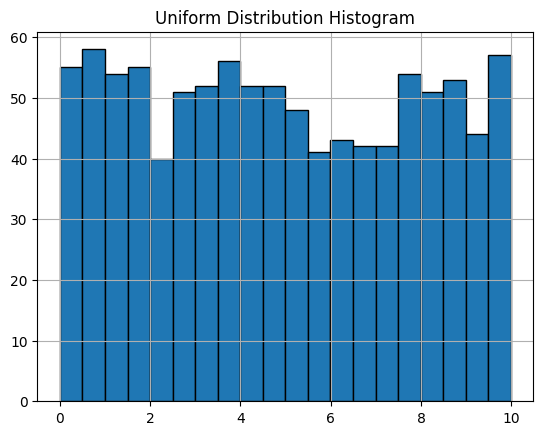

In [54]:
# Try sampling 1000 values and Plotting Histogram.

import matplotlib.pyplot as plt
import numpy as np

data = uniform.rvs(loc=0, scale=10, size=1000)
plt.hist(data, bins=20, edgecolor='black')
plt.title("Uniform Distribution Histogram")
plt.grid(True)
plt.show()


In [55]:
# Checking Constant CDF growth.

print("CDF at x = 6 in Uniform(0, 10):", uniform.cdf(6, loc=0, scale=10))


CDF at x = 6 in Uniform(0, 10): 0.6


## Predictable and Simple Statistics(Mean, Variance and Range).

- The Uniform Distribution has very Simple Formulas for Mean and Variance.

- Mean = (a + b)/2, where a is the start and b is the end of the Interval.

- Variance = (b - a)^2 / 12, so it only depends on the Width.

- These properties are helpful in simulations where Expected Values are Needed.

- There's no Mode because All Values are Equally Likely.

- These statistics are easily calculated using SciPy functions.

- The range is Fixed and known, which helps in Bounding Outputs.

- Knowing Mean and Variance helps in building Confidence Intervals.

- The Median is also Exactly in the Middle of the Interval.

- All these values are Symmetrical across the center of the Interval.

- The Simplicity makes it good for beginner-level Probability Modeling.

- Results from this distribution are predictable and easy to interpret

In [56]:
# Mean of Uniform(10, 20).

mean = uniform.mean(loc=10, scale=10)
print("Mean:", mean)


Mean: 15.0


In [57]:
# Variance of Uniform(0, 100).

var = uniform.var(loc=0, scale=100)
print("Variance:", var)


Variance: 833.3333333333333


In [58]:
# Median = mean for Uniform Distribution.

median = uniform.median(loc=0, scale=10)
print("Median:", median)


Median: 5.0


In [59]:
# Skewness and Kurtosis(should be 0 and -1.2).

print("Skewness:", uniform.stats(loc=0, scale=10, moments='s'))
print("Kurtosis:", uniform.stats(loc=0, scale=10, moments='k'))


Skewness: 0.0
Kurtosis: -1.2


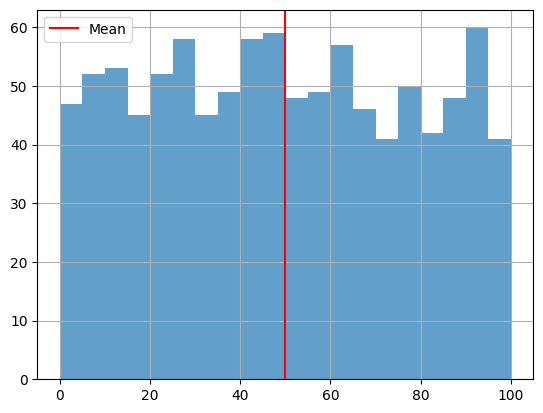

In [60]:
# Plot mean line over Histogram.

data = uniform.rvs(loc=0, scale=100, size=1000)
plt.hist(data, bins=20, alpha=0.7)
plt.axvline(x=uniform.mean(loc=0, scale=100), color='red', label='Mean')
plt.legend()
plt.grid(True)
plt.show()


In [61]:
# Summary of Basic Statistics.

print("Mean:", uniform.mean(10, 5))
print("Median:", uniform.median(10, 5))
print("Variance:", uniform.var(10, 5))
print("Standard Deviation:", uniform.std(10, 5))


Mean: 12.5
Median: 12.5
Variance: 2.083333333333333
Standard Deviation: 1.4433756729740643


## Used for Sampling in Simulations & Experiments.

- Uniform distribution is ideal for simulations that need random inputs.

- It is used in Monte Carlo methods, where large-scale random trials are performed.

- In Testing or Modeling, Uniform Samples act as Neutral Inputs.

- Game development often uses it to simulate fair random events.

- It's commonly used to randomly pick configurations in parameter tuning.

- Many Machine Learning Libraries use it for initial Random Weight Assignment.

- Uniform Sampling is Essential when no bias should exist in Random Choices.

- The Simplicity of Uniform Sampling speeds up Code Testing.

- Uniform Distribution helps in A/B Testing for Picking Control vs Treatment Groups.

- In scientific experiments, it is used for simulating ideal randomized trials.

- It allows generation of synthetic data for data science pipelines.

- Also used for Creating Baseline Models before using Complex Ones.

In [62]:
# Simulate 1000 Unbiased Coin Flips.

flips = uniform.rvs(loc=0, scale=1, size=1000)
coins = (flips > 0.5).astype(int)
print("Heads count:", sum(coins))


Heads count: 517


In [63]:
# Test a function using Random Uniform Input.

def calc(x): return 3 * x + 2

inputs = uniform.rvs(loc=0, scale=10, size=5)
outputs = calc(inputs)
print("Inputs:", inputs)
print("Outputs:", outputs)


Inputs: [4.56172634 4.19304084 5.50222071 2.31288788 9.68685266]
Outputs: [15.68517901 14.57912253 18.50666214  8.93866364 31.06055797]


In [64]:
# Random learning Rates for Model Tuning.

lr = uniform.rvs(loc=0.001, scale=0.009, size=5)
print("Random learning rates:", lr)


Random learning rates: [0.00976319 0.00959026 0.00274479 0.00584579 0.0086237 ]


## Beta Distribution in Contionous Distributions in SciPy. 

- The Beta Distribution is a Continuous Probability Distribution defined on the Interval[0, 1].

- It is controlled by two shape parameters: a (alpha) and b (beta), which determine the shape of the curve.

- The distribution is very flexible and can take many shapes: U-shaped, bell-shaped, skewed, or uniform-like.

- It's often used to Model Probabilities, Fractions, or Proportions, such as the Success Rate in trials.

- If a = b = 1, the Beta distribution becomes a Uniform distribution over [0, 1].

- If a > b, the distribution is skewed to the left; if a < b, it’s skewed to the right.

- The Beta distribution is bounded, meaning it’s only defined between 0 and 1.

- It’s commonly used in Bayesian statistics to represent prior or posterior beliefs.

- The Mean of the Beta distribution is a / (a + b).

- The variance is (a*b) / [(a + b)^2 * (a + b + 1)].

- It’s used in A/B testing, machine learning, and reinforcement learning (e.g., multi-armed bandits).

- SciPy provides it through scipy.stats.beta.



In [65]:
from scipy.stats import beta

# Generate a random value from Beta(a=2, b=5)
print("Sample:", beta.rvs(a=2, b=5))


Sample: 0.18903287556507636


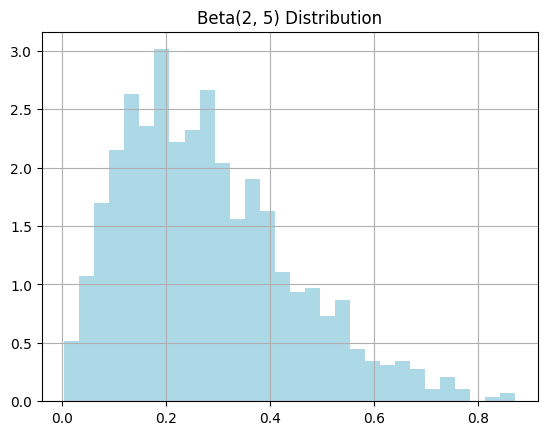

In [66]:
# Generate multiple samples and plot histogram.

import numpy as np
import matplotlib.pyplot as plt

samples = beta.rvs(a=2, b=5, size=1000)
plt.hist(samples, bins=30, density=True, color='lightblue')
plt.title("Beta(2, 5) Distribution")
plt.grid(True)
plt.show()


In [67]:
# PDF at x = 0.5.

print("PDF at x=0.5:", beta.pdf(0.5, a=2, b=5))


PDF at x=0.5: 0.9374999999999999


In [68]:
# CDF at x = 0.7.

print("CDF at x=0.7:", beta.cdf(0.7, a=2, b=5))


CDF at x=0.7: 0.989065


In [69]:
# Mean and Variance of Beta(2, 5).

print("Mean:", beta.mean(2, 5))
print("Variance:", beta.var(2, 5))


Mean: 0.2857142857142857
Variance: 0.025510204081632654


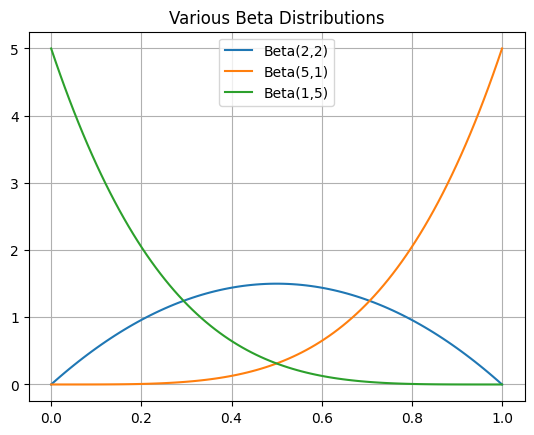

In [70]:
# Create different Beta shapes.

x = np.linspace(0, 1, 100)
plt.plot(x, beta.pdf(x, 2, 2), label='Beta(2,2)')
plt.plot(x, beta.pdf(x, 5, 1), label='Beta(5,1)')
plt.plot(x, beta.pdf(x, 1, 5), label='Beta(1,5)')
plt.legend()
plt.title("Various Beta Distributions")
plt.grid(True)
plt.show()


## Features of Beta Distribution in Contionous Distributions in SciPy.

## Highly Flexible Shape.

- The Beta Distribution is Extremely Flexible in Shape, Depending on a and b.

- When both Parameters are < 1, it Produces a U-shape with Peaks near 0 and 1.

- When both parameters are > 1, it gives a bell-shaped curve.

- If a > b, the distribution is skewed left; if a < b, it’s skewed right.

- With a = b = 1, it becomes a uniform distribution.

- This flexibility allows it to Model Real - World Probabilities(like CTRs, Conversion Rates, etc.).

- It also works well for Modeling Prior Distributions in Bayesian Inference.

- You can Graphically adjust a and b to shape your Belief Distribution.

- The shape reflects certainty or uncertainty in expected outcomes.

- Beta is bounded — always between 0 and 1 — which is useful for modeling proportions.

- It's Skewness and Shape make it ideal for Decision Theory and Risk Assessment.

- Its Graphical forms are Smooth and Mathematically Stable for Statistical Analysis.

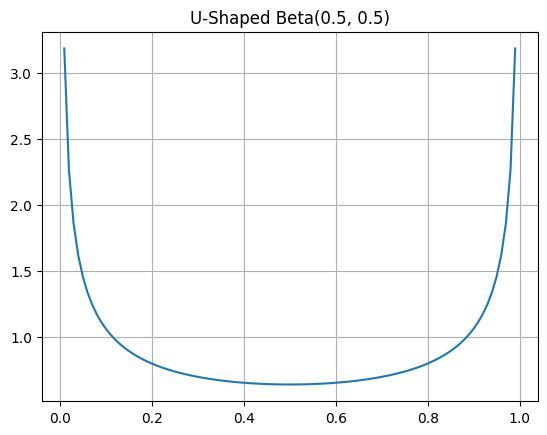

In [71]:
# U - Shaped Distribution.

x = np.linspace(0, 1, 100)
plt.plot(x, beta.pdf(x, 0.5, 0.5))
plt.title("U-Shaped Beta(0.5, 0.5)")
plt.grid(True)
plt.show()


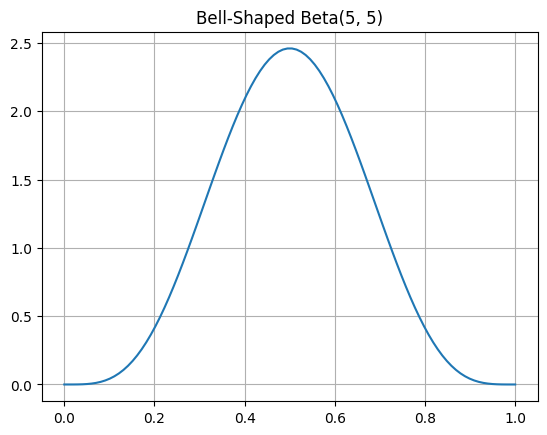

In [72]:
# Bell- Shaped Distribution.

plt.plot(x, beta.pdf(x, 5, 5))
plt.title("Bell-Shaped Beta(5, 5)")
plt.grid(True)
plt.show()


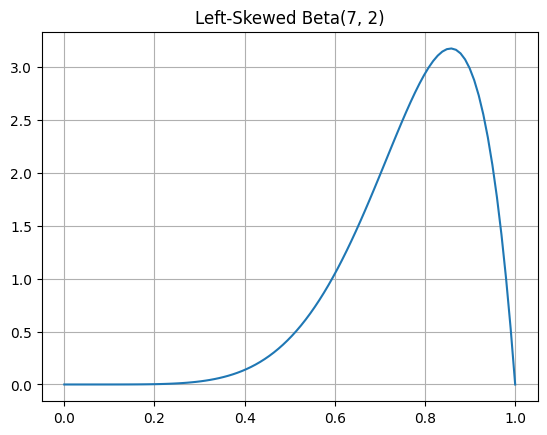

In [73]:
# Left-skewed (a > b).

plt.plot(x, beta.pdf(x, 7, 2))
plt.title("Left-Skewed Beta(7, 2)")
plt.grid(True)
plt.show()


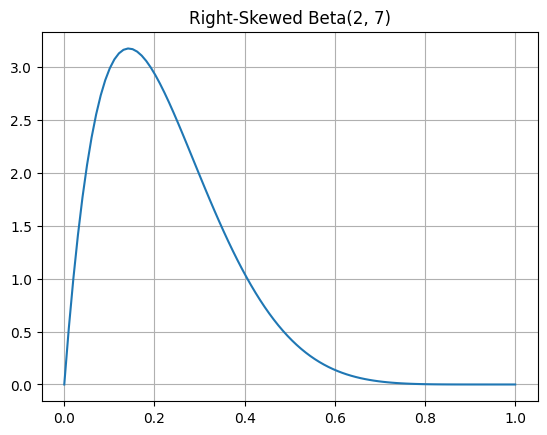

In [74]:
# Right-skewed(a < b).

plt.plot(x, beta.pdf(x, 2, 7))
plt.title("Right-Skewed Beta(2, 7)")
plt.grid(True)
plt.show()


## Perfect for Bayesian Inference.


- The Beta Distribution is the conjugate prior for the binomial likelihood in Bayesian statistics.

- It means if your likelihood is binomial (e.g., number of successes), and your prior is Beta, the posterior is also Beta.

- This makes it mathematically convenient for belief updating.

- A/B testing often models conversion rates using Beta distributions.

- You start with prior beliefs (e.g., Beta(1,1)) and update based on outcomes (successes and failures).

- If you observe 3 Successes and 2 Failures, the Updated Distribution becomes Beta(4,3).

- The more data you have, the tighter the distribution becomes — indicating more certainty.

- This is used in online learning, recommender systems, and ad testing.

- Each new observation updates the shape of the belief using simple addition: a += successes, b += failures.

- The posterior gives you both a distribution and a confidence interval.

- You can then sample from the posterior to make probabilistic decisions.

- This Ability to represent Dynamic beliefs makes Beta extremely Powerful in Practice.

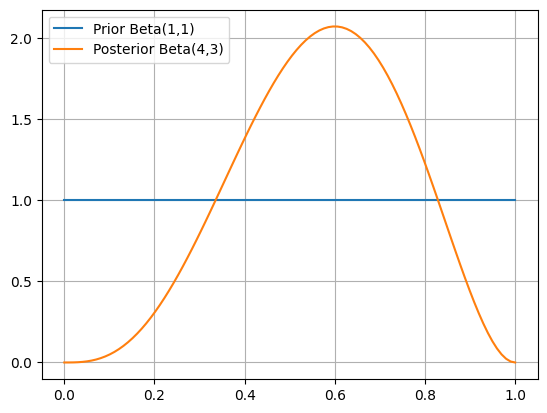

In [75]:
# Starting with niform prior.

prior = beta(1, 1)

# Update after 3 successes and 2 failures
posterior = beta(1 + 3, 1 + 2)

# Plot the prior vs posterior
x = np.linspace(0, 1, 100)
plt.plot(x, prior.pdf(x), label='Prior Beta(1,1)')
plt.plot(x, posterior.pdf(x), label='Posterior Beta(4,3)')
plt.legend()
plt.grid(True)
plt.show()


In [76]:
# 95% Confidence Interval.

ci = beta.interval(0.95, 4, 3)
print("95% confidence interval:", ci)


95% confidence interval: (0.22277809550351216, 0.8818827512429748)


In [77]:
# Compare Two Options(A/B testing).

# A: 4 successes, 3 failures
# B: 6 successes, 4 failures
samples_a = beta.rvs(4, 3, size=10000)
samples_b = beta.rvs(6, 4, size=10000)

# Probability that A is better than B
prob_a_better = (samples_a > samples_b).mean()
print("Probability A > B:", prob_a_better)


Probability A > B: 0.4644
